In [1]:
# 1. INSTALL AND IMPORT LIBRARIES

!pip install ultralytics -q

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files

import warnings
warnings.filterwarnings("ignore")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 9.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [2]:

# 2. LOAD PRETRAINED YOLOv8 MODEL

model = YOLO("yolov8n.pt")

print("\nModel Loaded: YOLOv8n")
print("Number of Classes:", len(model.names))
print("First 10 Classes:", list(model.names.values())[:10])

# 3. TRAIN (FINE-TUNE) THE MODEL ON A SMALL DATASET
# coco8 is a small sample of the COCO dataset (8 images).
# It is downloaded automatically by Ultralytics.

train_results = model.train(
    data="coco8.yaml",
    epochs=10,
    imgsz=640,
    batch=8,
    verbose=False
)


Model Loaded: YOLOv8n
Number of Classes: 80
First 10 Classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mix

In [3]:
# 4. EVALUATE THE MODEL

metrics = model.val()

print("\nPrecision :", round(metrics.box.mp, 4))
print("Recall    :", round(metrics.box.mr, 4))
print("mAP@0.50  :", round(metrics.box.map50, 4))
print("mAP@0.50:0.95 :", round(metrics.box.map, 4))


Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1581.8±658.6 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 986.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 10.0it/s 0.1s
                   all          4         17      0.693       0.75      0.893      0.622
                person          3         10      0.635        0.5      0.549      0.282
                   dog          1          1      0.461          1      0.995      0.697
                 horse          1          2      0.715          1      0.995      0.645
              elephant          1          2          1          0      0.828      0.215
              umbrella          1          1     


Upload an image for object detection:


Saving images.png to images.png


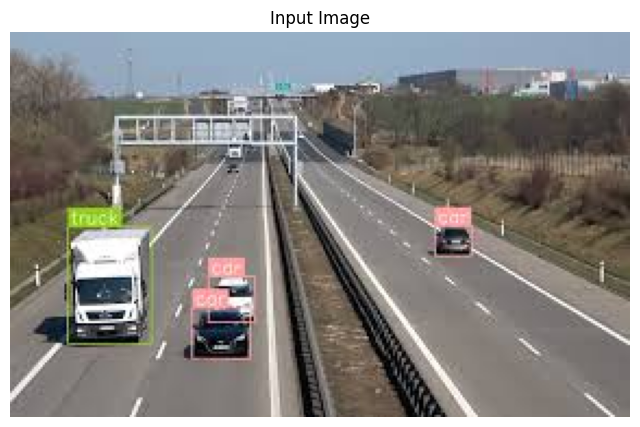


Detected Objects:
------------------------------------------------------------
truck | Confidence: 0.63 | Box: [26, 89, 65, 143]
car | Confidence: 0.63 | Box: [194, 90, 212, 102]
truck | Confidence: 0.49 | Box: [192, 79, 212, 102]
truck | Confidence: 0.33 | Box: [81, 116, 111, 149]
car | Confidence: 0.32 | Box: [84, 133, 110, 148]
bus | Confidence: 0.29 | Box: [25, 89, 65, 143]
------------------------------------------------------------
Total Objects Detected: 6


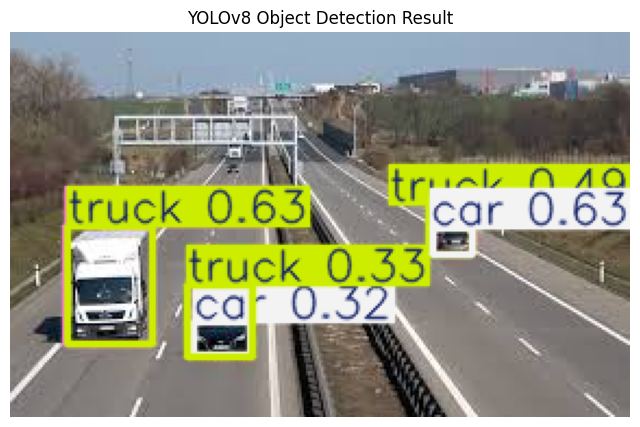

In [5]:
# 5. UPLOAD INPUT IMAGE

print("\nUpload an image for object detection:")

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# 6. DISPLAY ORIGINAL IMAGE

original = cv2.imread(image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(original)
plt.title("Input Image")
plt.axis("off")
plt.show()

# 7. PERFORM OBJECT DETECTION

results = model.predict(source=image_path, conf=0.25, verbose=False)
result = results[0]

# 8. PRINT DETECTED OBJECTS

print("\nDetected Objects:")
print("-" * 60)

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    print(
        model.names[class_id],
        "| Confidence:", round(confidence, 2),
        "| Box:", [int(x1), int(y1), int(x2), int(y2)]
    )

print("-" * 60)
print("Total Objects Detected:", len(result.boxes))

# 9. DISPLAY DETECTION RESULT

annotated = result.plot()
annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(annotated)
plt.title("YOLOv8 Object Detection Result")
plt.axis("off")
plt.show()



In [6]:
# 10. DISPLAY FINAL RESULTS

print("\n===================================")
print("          FINAL RESULT")
print("===================================")
print("YOLOv8 object detection completed successfully.")
print("Model Used:", "YOLOv8n")
print("Objects Detected:", len(result.boxes))
print("mAP@0.50:", round(metrics.box.map50, 4))


          FINAL RESULT
YOLOv8 object detection completed successfully.
Model Used: YOLOv8n
Objects Detected: 6
mAP@0.50: 0.8928
